# Sentiment Analysis of Reviews

本 Notebook 依照指定架構整理。目標是比較三種資料設定下的情感分類表現。

1. 技術方法 / 模型流程
2. 實驗一：IMDB 訓練與測試
3. 實驗二：IMDB 模型測 Amazon
4. 實驗三：IMDB + Amazon 混合資料
5. 結果比較與分析


## 技術方法 / 模型流程

本專題使用 TF-IDF 將評論文字轉成數值特徵，並使用 Logistic Regression 進行二元情感分類。標籤統一為 `0 = Negative`、`1 = Positive`。

流程：資料讀取 → 文字清理 → 標籤轉換 → 資料切分 → TF-IDF 特徵抽取 → 模型訓練 → 結果評估。


In [1]:
# Import packages for data processing, text cleaning, plotting, and modeling.
import pandas as pd
import numpy as np
import re
from html import unescape
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

RANDOM_STATE = 42
english_stopwords = stopwords.words('english')
experiment_results = []


In [2]:
def clean_text(text: str) -> str:
    """Clean one review by removing HTML noise and repeated spaces."""
    text = unescape(str(text))
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix', class_labels=('Negative', 'Positive')):
    """Plot a confusion matrix for binary sentiment classification."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(class_labels), yticklabels=list(class_labels))
    plt.title(title)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()


def add_experiment_result(experiment_name: str, accuracy: float, train_size: int, test_size: int, note: str):
    """Save the main result of each experiment for final comparison."""
    experiment_results.append({
        'Experiment': experiment_name,
        'Accuracy': accuracy,
        'Train Size': train_size,
        'Test Size': test_size,
        'Note': note,
    })


## 實驗一：IMDB 訓練與測試

實驗一只使用 IMDB 電影評論。80% 資料用於訓練，20% 資料用於測試，作為同領域資料的基準結果。


C:\Users\user\AppData\Local\Temp\ipykernel_20508\3843042107.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=imdb_df, palette='Set2')


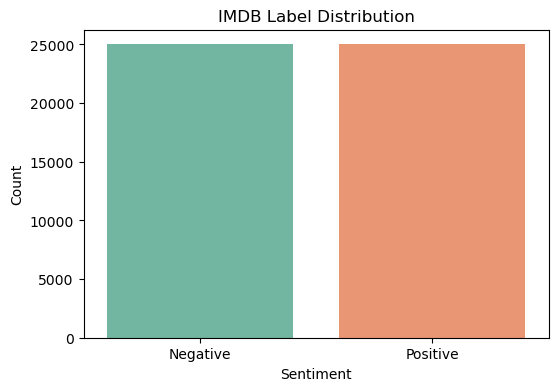

In [3]:
# Load and clean the IMDB dataset.
imdb_path = Path('IMDB_Dataset.csv')
if not imdb_path.exists():
    raise FileNotFoundError(f'File not found: {imdb_path}')

imdb_df = pd.read_csv(imdb_path)
imdb_df['review'] = imdb_df['review'].fillna('').map(clean_text)
imdb_df['sentiment'] = imdb_df['sentiment'].astype(str).str.lower().str.strip().map({'positive': 1, 'negative': 0})

if imdb_df['sentiment'].isna().any():
    raise ValueError('IMDB sentiment contains labels that cannot be converted.')

plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=imdb_df, palette='Set2')
plt.title('IMDB Label Distribution')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


== Experiment 1: IMDB train/test ==
Accuracy: 0.8930

              precision    recall  f1-score   support

    Negative     0.8989    0.8856    0.8922      5000
    Positive     0.8873    0.9004    0.8938      5000

    accuracy                         0.8930     10000
   macro avg     0.8931    0.8930    0.8930     10000
weighted avg     0.8931    0.8930    0.8930     10000



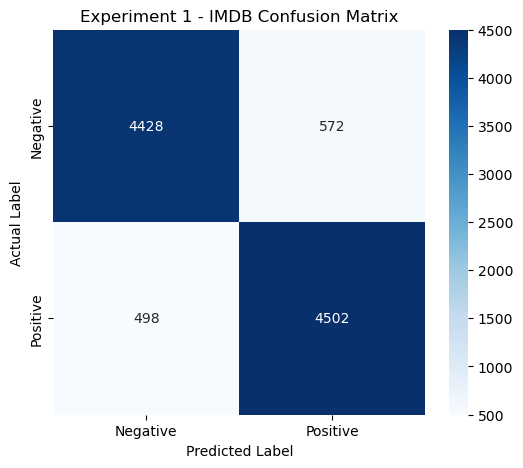

In [4]:
# Split IMDB data, train the baseline model, and evaluate it on IMDB test data.
X_train, X_test, y_train, y_test = train_test_split(
    imdb_df['review'],
    imdb_df['sentiment'],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=imdb_df['sentiment'],
)

vectorizer = TfidfVectorizer(lowercase=True, stop_words=english_stopwords, max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train_tfidf, y_train)

imdb_pred = model.predict(X_test_tfidf)
imdb_accuracy = accuracy_score(y_test, imdb_pred)

print('== Experiment 1: IMDB train/test ==')
print(f'Accuracy: {imdb_accuracy:.4f}')
print()
print(classification_report(y_test, imdb_pred, target_names=['Negative', 'Positive'], digits=4))

plot_confusion_matrix(y_test, imdb_pred, title='Experiment 1 - IMDB Confusion Matrix')

add_experiment_result(
    'Exp 1: IMDB train/test',
    imdb_accuracy,
    len(X_train),
    len(X_test),
    'Baseline result on the same data source.',
)


In [5]:
def predict_my_review(custom_review: str) -> None:
    """Predict one custom review with the IMDB baseline model."""
    cleaned = clean_text(custom_review)
    X_custom = vectorizer.transform([cleaned])
    pred = model.predict(X_custom)[0]
    proba = model.predict_proba(X_custom)[0]
    confidence = proba[int(pred)] * 100
    label = 'Positive' if int(pred) == 1 else 'Negative'

    print('-' * 60)
    print('Input review:')
    print(custom_review)
    print()
    print(f'Prediction: {label}')
    print(f'Confidence: {confidence:.2f}%')
    print('-' * 60)


for example in [
    'This product is absolutely amazing and exceeded my expectations.',
    'Terrible quality. It broke after one use and I would not buy it again.',
    'The item arrived on time, but the battery life is disappointing.',
]:
    predict_my_review(example)


------------------------------------------------------------
Input review:
This product is absolutely amazing and exceeded my expectations.

Prediction: Positive
Confidence: 77.59%
------------------------------------------------------------
------------------------------------------------------------
Input review:
Terrible quality. It broke after one use and I would not buy it again.

Prediction: Negative
Confidence: 91.20%
------------------------------------------------------------
------------------------------------------------------------
Input review:
The item arrived on time, but the battery life is disappointing.

Prediction: Negative
Confidence: 85.81%
------------------------------------------------------------


## 實驗二：IMDB 模型測 Amazon

實驗二不重新訓練模型，直接用實驗一的 IMDB 模型預測 Amazon 評論。`overall` 星等轉為實際標籤：4-5 星為正評，1-2 星為負評，3 星排除於評估之外。


== Experiment 2: IMDB model on Amazon ==
Rule: overall 4-5 = Positive, 1-2 = Negative, 3 = excluded
Used rows for evaluation: 4773 / 4915
Accuracy: 0.7653

              precision    recall  f1-score   support

    Negative     0.1806    0.6944    0.2866       324
    Positive     0.9719    0.7705    0.8596      4449

    accuracy                         0.7653      4773
   macro avg     0.5763    0.7325    0.5731      4773
weighted avg     0.9182    0.7653    0.8207      4773



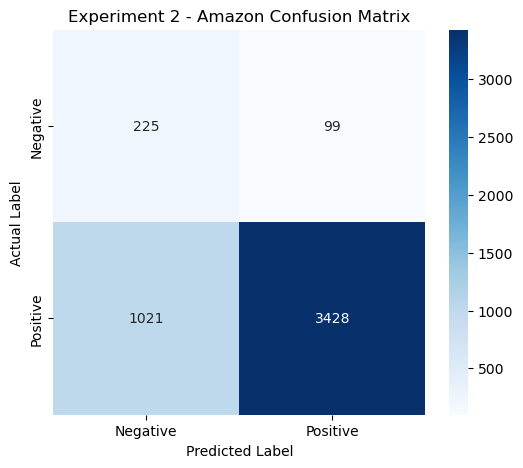

In [6]:
# Load Amazon reviews and convert star ratings into binary sentiment labels.
amazon_path = Path('amazon_reviews.csv')
if not amazon_path.exists():
    raise FileNotFoundError(f'File not found: {amazon_path}')

amazon_df = pd.read_csv(amazon_path)
required_columns = {'reviewText', 'overall'}
missing_columns = required_columns - set(amazon_df.columns)
if missing_columns:
    raise ValueError(f'Missing Amazon columns: {missing_columns}')

amazon_df['reviewText'] = amazon_df['reviewText'].fillna('')
amazon_df['cleaned_review'] = amazon_df['reviewText'].map(clean_text)

amazon_df['actual_sentiment'] = pd.NA
amazon_df.loc[amazon_df['overall'].between(4.0, 5.0, inclusive='both'), 'actual_sentiment'] = 1
amazon_df.loc[amazon_df['overall'].between(1.0, 2.0, inclusive='both'), 'actual_sentiment'] = 0
amazon_eval_df = amazon_df.dropna(subset=['actual_sentiment']).copy()
amazon_eval_df['actual_sentiment'] = amazon_eval_df['actual_sentiment'].astype(int)

X_amazon = vectorizer.transform(amazon_df['cleaned_review'])
amazon_df['predicted_sentiment'] = model.predict(X_amazon)
amazon_eval_df['predicted_sentiment'] = amazon_df.loc[amazon_eval_df.index, 'predicted_sentiment']

amazon_accuracy = accuracy_score(amazon_eval_df['actual_sentiment'], amazon_eval_df['predicted_sentiment'])

print('== Experiment 2: IMDB model on Amazon ==')
print('Rule: overall 4-5 = Positive, 1-2 = Negative, 3 = excluded')
print(f'Used rows for evaluation: {len(amazon_eval_df)} / {len(amazon_df)}')
print(f'Accuracy: {amazon_accuracy:.4f}')
print()
print(classification_report(amazon_eval_df['actual_sentiment'], amazon_eval_df['predicted_sentiment'], target_names=['Negative', 'Positive'], digits=4))

plot_confusion_matrix(amazon_eval_df['actual_sentiment'], amazon_eval_df['predicted_sentiment'], title='Experiment 2 - Amazon Confusion Matrix')

add_experiment_result(
    'Exp 2: IMDB model on Amazon',
    amazon_accuracy,
    len(X_train),
    len(amazon_eval_df),
    'Cross-domain test: train on IMDB and test on Amazon.',
)


== Amazon prediction distribution ==
Total: 4915
Negative (0): 1331
Positive (1): 3584


C:\Users\user\AppData\Local\Temp\ipykernel_20508\665993346.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='predicted_sentiment', data=amazon_df, palette='Set2')


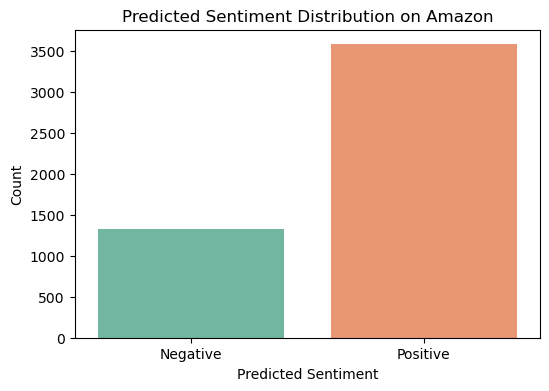

== Amazon examples: first 5 rows ==


,reviewText,overall,predicted_sentiment
0,No issues.,4.0,1
1,"Purchased this for my device, it worked as adv...",5.0,1
2,it works as expected. I should have sprung for...,4.0,1
3,This think has worked out great.Had a diff. br...,5.0,1
4,"Bought it with Retail Packaging, arrived legit...",5.0,1


In [7]:
# Inspect Amazon prediction distribution and a few examples.
pred_counts = amazon_df['predicted_sentiment'].value_counts().sort_index()
print('== Amazon prediction distribution ==')
print(f'Total: {len(amazon_df)}')
print(f"Negative (0): {int(pred_counts.get(0, 0))}")
print(f"Positive (1): {int(pred_counts.get(1, 0))}")

plt.figure(figsize=(6, 4))
sns.countplot(x='predicted_sentiment', data=amazon_df, palette='Set2')
plt.title('Predicted Sentiment Distribution on Amazon')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.xlabel('Predicted Sentiment')
plt.ylabel('Count')
plt.show()

print('== Amazon examples: first 5 rows ==')
display(amazon_df[['reviewText', 'overall', 'predicted_sentiment']].head())


## 實驗三：IMDB + Amazon 混合資料

實驗三將 IMDB 與 Amazon 可用標籤資料合併。兩個資料集各切一半：一半加入訓練集，另一半加入測試集。


In [8]:
# Build a mixed IMDB + Amazon dataset with the same column format.
amazon_labeled_df = amazon_eval_df.copy()
amazon_labeled_df['review'] = amazon_df.loc[amazon_labeled_df.index, 'cleaned_review']
amazon_labeled_df['sentiment'] = amazon_labeled_df['actual_sentiment']
amazon_labeled_df = amazon_labeled_df[['review', 'sentiment']]

imdb_for_mix = imdb_df[['review', 'sentiment']].copy()

imdb_train, imdb_test = train_test_split(
    imdb_for_mix,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=imdb_for_mix['sentiment'],
)
amazon_train, amazon_test = train_test_split(
    amazon_labeled_df,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=amazon_labeled_df['sentiment'],
)

mixed_train_df = pd.concat([imdb_train, amazon_train], ignore_index=True)
mixed_test_df = pd.concat([imdb_test, amazon_test], ignore_index=True)

print('== Mixed dataset split ==')
print(f"Train size: {len(mixed_train_df)} (IMDB: {len(imdb_train)}, Amazon: {len(amazon_train)})")
print(f"Test size : {len(mixed_test_df)} (IMDB: {len(imdb_test)}, Amazon: {len(amazon_test)})")


== Mixed dataset split ==
Train size: 27386 (IMDB: 25000, Amazon: 2386)
Test size : 27387 (IMDB: 25000, Amazon: 2387)


== Experiment 3: IMDB + Amazon mixed data ==
Accuracy: 0.8872

              precision    recall  f1-score   support

    Negative     0.8935    0.8585    0.8756     12662
    Positive     0.8823    0.9120    0.8969     14725

    accuracy                         0.8872     27387
   macro avg     0.8879    0.8852    0.8863     27387
weighted avg     0.8874    0.8872    0.8871     27387



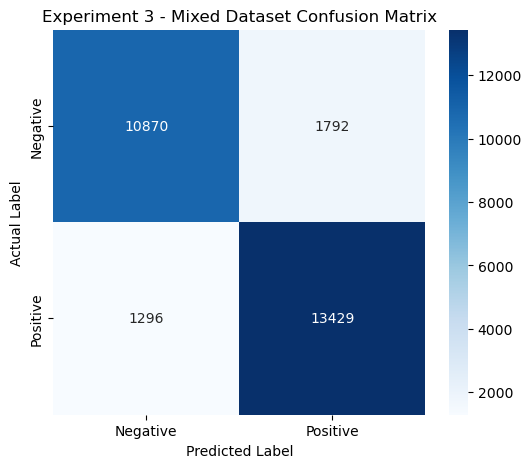

== Mixed test examples: first 5 rows ==


,review,sentiment,predicted_sentiment
0,If you are a six-year-old boy who's into dinos...,0,0
1,"When I voted my ""1"" for this film I noticed th...",0,0
2,"While there aren't any talking animals, big la...",1,1
3,"Did you ever think, like after watching a horr...",0,0
4,"I was expecting to love this movie--film noir,...",0,0


In [9]:
# Train and evaluate a new model with mixed-domain training data.
mixed_vectorizer = TfidfVectorizer(lowercase=True, stop_words=english_stopwords, max_features=5000)
X_train_mixed = mixed_vectorizer.fit_transform(mixed_train_df['review'])
X_test_mixed = mixed_vectorizer.transform(mixed_test_df['review'])
y_train_mixed = mixed_train_df['sentiment']
y_test_mixed = mixed_test_df['sentiment']

mixed_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
mixed_model.fit(X_train_mixed, y_train_mixed)
mixed_pred = mixed_model.predict(X_test_mixed)
mixed_accuracy = accuracy_score(y_test_mixed, mixed_pred)

print('== Experiment 3: IMDB + Amazon mixed data ==')
print(f'Accuracy: {mixed_accuracy:.4f}')
print()
print(classification_report(y_test_mixed, mixed_pred, target_names=['Negative', 'Positive'], digits=4))

plot_confusion_matrix(y_test_mixed, mixed_pred, title='Experiment 3 - Mixed Dataset Confusion Matrix')

add_experiment_result(
    'Exp 3: IMDB + Amazon mixed',
    mixed_accuracy,
    len(mixed_train_df),
    len(mixed_test_df),
    'Mixed-domain train/test setting.',
)

mixed_preview = mixed_test_df.copy()
mixed_preview['predicted_sentiment'] = mixed_pred
print('== Mixed test examples: first 5 rows ==')
display(mixed_preview.head())


## 結果比較與分析

最後將三個實驗的 Accuracy 放在同一張表和長條圖中比較。實驗一是同領域基準，實驗二檢查跨領域落差，實驗三觀察混合資料是否能改善整體表現。


,Experiment,Accuracy,Train Size,Test Size,Note
0,Exp 1: IMDB train/test,0.8930,40000,10000,Baseline result on the same data source.
1,Exp 2: IMDB model on Amazon,0.7653,40000,4773,Cross-domain test: train on IMDB and test on A...
2,Exp 3: IMDB + Amazon mixed,0.8872,27386,27387,Mixed-domain train/test setting.


C:\Users\user\AppData\Local\Temp\ipykernel_20508\1275429729.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result_df, x='Experiment', y='Accuracy', palette='Set2')


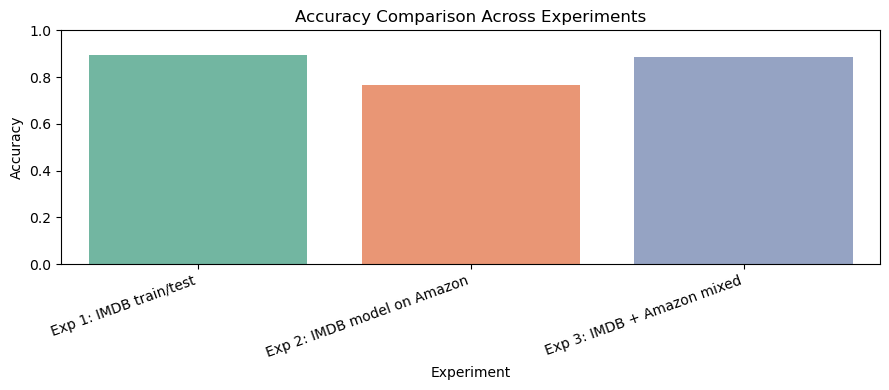

In [10]:
# Summarize all experiments for final comparison.
result_df = pd.DataFrame(experiment_results)
result_df['Accuracy'] = result_df['Accuracy'].round(4)

display(result_df)

plt.figure(figsize=(9, 4))
sns.barplot(data=result_df, x='Experiment', y='Accuracy', palette='Set2')
plt.ylim(0, 1)
plt.title('Accuracy Comparison Across Experiments')
plt.xlabel('Experiment')
plt.ylabel('Accuracy')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


### 分析重點

- 實驗一代表 IMDB 同領域的基準表現。
- 實驗二若明顯下降，表示電影評論與商品評論的語言分布不同。
- 實驗三若高於實驗二，表示加入 Amazon 資料有助於模型適應商品評論。
- 若實驗三沒有提升，可能與資料比例、標籤規則或 TF-IDF 特徵限制有關。
